In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# PARAMETERS
M = 4              # nbre of messages
n = 2              # channel dimension
train_SNR_dB = 10  # The SNR level we are training the architecture on
batch_size = 128
epochs = 2000
criterion = nn.CrossEntropyLoss()
lr = 0.01
SNR_range_dB = torch.arange(-10, 21, 1)
test_size = 20000

In [63]:
############### Encoder architecture #########################
class Encoder(nn.Module):
    def __init__(self, M, n):
        super().__init__()
        self.fc = nn.Linear(M, n)

    def forward(self, x):
        x = self.fc(x)
        x = x / torch.sqrt(torch.mean(x**2)) # Power normalization

        return x

In [64]:
########### the AWGN channel #################
def add_awgn(x , snr_db):
    SNR = 10 ** (snr_db / 10)
    noise_std = (1 / (2 * SNR)) ** 0.5
    noise = noise_std * torch.randn_like(x)
    return x + noise

In [65]:
############## Decoder architecture ###############
class Decoder(nn.Module):
    def __init__(self, M, n):
        super().__init__()
        self.fc = nn.Linear(n, M)

    def forward(self, x):
        return self.fc(x)  # logits

In [66]:
################# AUTOENCODER ###################
class Autoencoder(nn.Module):
    def __init__(self, M, n):
        super().__init__()
        self.encoder = Encoder(M, n)
        self.decoder = Decoder(M, n)

    def forward(self, x, SNR_dB):
        x = self.encoder(x)
        x = add_awgn(x, SNR_dB)
        x = self.decoder(x)
        return x

In [67]:
model = Autoencoder(M, n)
optimizer = torch.optim.Adam(model.parameters(), lr)

############## TRAINING ##################
for epoch in range(epochs):

    # During training we want the autoencoder to learn how to transmit any message of length M
    # we are not here transmitting a single messgae, we want to design a communication system that can
    # learn the geometry of the constellation
    # (During training, we are not sending one specific message we are teaching the system to handle all possible messages)
    labels = torch.randint(0, M, (batch_size,))

    inputs = F.one_hot(labels, num_classes=M).float() # one hot encoding because we feed vectors to the encoder not indices

    outputs = model(inputs, train_SNR_dB)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.5163
Epoch 200, Loss: 0.1494
Epoch 400, Loss: 0.0535
Epoch 600, Loss: 0.0342
Epoch 800, Loss: 0.0253
Epoch 1000, Loss: 0.0168
Epoch 1200, Loss: 0.0117
Epoch 1400, Loss: 0.0093
Epoch 1600, Loss: 0.0111
Epoch 1800, Loss: 0.0086


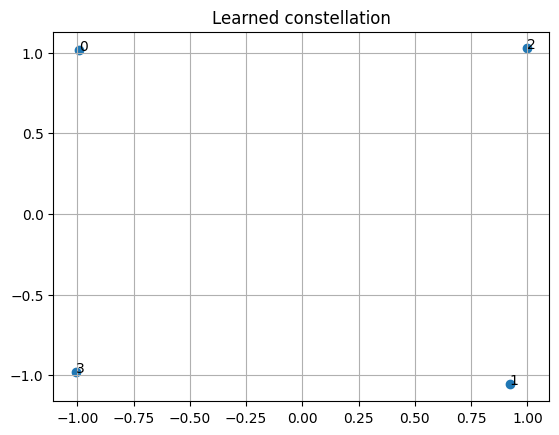

In [68]:
############ The learned constellations ##############
############ we give the learned encoder all possible messages for M ####
############ and we verify if it rediscoverd the optimal constellation ####

with torch.no_grad(): # we evaluate what the model has learned

    identity = torch.eye(M) # This is the identity matrix that has
                            # all the possible messages (lines) at once

    constellation = model.encoder(identity)

points = constellation.numpy()

# ploting the constellations
plt.scatter(points[:, 0], points[:, 1])
for i in range(M):
    plt.text(points[i, 0], points[i, 1], str(i))
plt.title("Learned constellation")
plt.grid()
plt.show()

**IT REDISCOVERS A QPSK CONSTELLATION !!!**

In [69]:
################### QPSK ######################
qpsk_constellation = torch.tensor([[1, 1],[1, -1],[-1, 1],[-1, -1]], dtype=torch.float32)
qpsk_constellation = qpsk_constellation / torch.sqrt(torch.mean(qpsk_constellation**2))

def qpsk_transmit(labels, SNR_dB):
    x = qpsk_constellation[labels]
    SNR = 10 ** (SNR_dB / 10)
    noise_std = (1 / (2 * SNR)) ** 0.5
    noise = noise_std * torch.randn_like(x)
    return x + noise

def qpsk_decode(y): # this is maximum likelihood decoding (we minimize euclidean distance)
    distances = torch.cdist(y, qpsk_constellation)
    return torch.argmin(distances, dim=1)

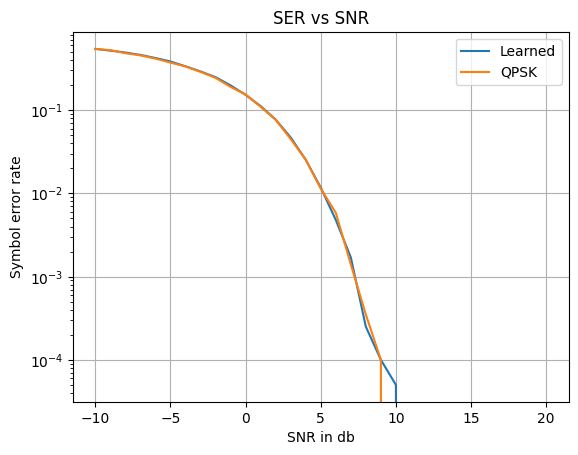

In [71]:
# TEST DATA
test_labels = torch.randint(0, M, (test_size,))
test_inputs = F.one_hot(test_labels, num_classes=M).float()


################## EVALUATION FUNCTIONS ##################
def evaluate_model(model, inputs, labels, SNR_dB):
    with torch.no_grad():
        outputs = model(inputs, SNR_dB)
        preds = torch.argmax(outputs, dim=1)
        return (preds != labels).float().mean().item()

def evaluate_qpsk(labels, SNR_dB):
    with torch.no_grad():
        y = qpsk_transmit(labels, SNR_dB)
        preds = qpsk_decode(y)
        return (preds != labels).float().mean().item()

################# Symbol error rate ##################
model_SER = []
qpsk_SER = []

for snr in SNR_range_dB:
    model_SER.append(evaluate_model(model, test_inputs, test_labels, snr.item()))
    qpsk_SER.append(evaluate_qpsk(test_labels, snr.item()))

# The plots
plt.semilogy(SNR_range_dB.numpy(), model_SER, label="Learned")
plt.semilogy(SNR_range_dB.numpy(), qpsk_SER, label="QPSK")

plt.xlabel("SNR in db")
plt.ylabel("Symbol error rate")
plt.title("SER vs SNR")
plt.legend()
plt.grid()
plt.show()